In [1]:
import os
import re
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
from nltk.tokenize import TweetTokenizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

class Config:
    max_len = 50
    embed_dim = 300
    hidden_dim = 512
    num_layers = 4
    dropout = 0.5
    bidirectional = True
    batch_size = 64
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    seed = 42

config = Config()

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.seed)
print(f"Using device: {config.device}")

Using device: cuda


In [2]:
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)

    def forward(self, lstm_outputs):
        attn_output, _ = self.mha(lstm_outputs, lstm_outputs, lstm_outputs)
        return torch.max(attn_output, dim=1)[0]

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, pretrained_embeddings, config):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=0)
        self.cnn = nn.Conv1d(in_channels=config.embed_dim, out_channels=config.embed_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.cnn_dropout = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            config.embed_dim, config.hidden_dim, num_layers=config.num_layers,
            batch_first=True, bidirectional=True, dropout=0.3 if config.num_layers > 1 else 0
        )

        lstm_out_dim = config.hidden_dim * 2
        self.attention = MultiHeadAttentionLayer(lstm_out_dim, num_heads=8)

        self.fc = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim),
            nn.LayerNorm(lstm_out_dim),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.LayerNorm(lstm_out_dim // 2),
            nn.GELU(),
            nn.Dropout(0.3),
             # nn.Linear(lstm_out_dim // 2, 1)
            # Multiclass Classification. 
            nn.Linear(lstm_out_dim // 2, 3) 
        )

    def forward(self, x, return_features=False):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.relu(self.cnn(x))
        x = self.cnn_dropout(x)
        x = x.transpose(1, 2)

        lstm_out, _ = self.lstm(x)
        attn_features = self.attention(lstm_out)

        if return_features:
            return attn_features

        x = self.fc(attn_features)
        # return x.squeeze()
        return x  # Just return x, no squeeze needed for multiclass

In [3]:
# 1. Load the Checkpoint Dictionary
checkpoint_path = '/kaggle/input/notebooks/anumitkumarjana/sentiment140-glove-cnn-bilstm-attn-v9/checkpoint_best_acc.pt' # Change to your actual file name
# FIX: Add weights_only=False to bypass the strict check
checkpoint = torch.load(checkpoint_path, map_location=config.device, weights_only=False)

# Extract vocabulary mapping
word2idx = checkpoint['word2idx']
vocab_size = len(word2idx)
print(f"Loaded vocabulary size: {vocab_size}")

# 2. Rebuild the GloVe Embedding Matrix
print("Rebuilding GloVe Embeddings...")
glove_path = '/kaggle/input/datasets/wiseyy/glove6b300dtxt/glove.6B.300d.txt'
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        embeddings_index[word] = np.asarray(values[1:], dtype='float32')

embedding_matrix = np.zeros((vocab_size, config.embed_dim))
for word, i in word2idx.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        if i != 0:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(config.embed_dim, ))

embedding_matrix_tensor = torch.FloatTensor(embedding_matrix)

# 3. Instantiate Model and Load Weights
model = SentimentModel(vocab_size, embedding_matrix_tensor, config).to(config.device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set to evaluation mode immediately
print("✅ Pre-trained model weights loaded successfully!")

Loaded vocabulary size: 15000
Rebuilding GloVe Embeddings...
✅ Pre-trained model weights loaded successfully!


In [4]:
print("Loading and cleaning dataset...")
# column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
# df = pd.read_csv('/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv',
#                 encoding='latin-1', header=None, names=column_names)
df_train = pd.read_csv('/kaggle/input/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/sentiment_train.csv',
                encoding = 'latin-1', header = 0)
df_test = pd.read_csv('/kaggle/input/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/sentiment_test.csv', 
                      encoding = 'latin-1' , header = 0)
df_validation = pd.read_csv('/kaggle/input/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/sentiment_validation.csv',
                       encoding = 'latin-1' , header = 0)
df_train.rename(columns={'label': 'target'}, inplace=True)
df_test.rename(columns={'label': 'target'}, inplace=True)
df_validation.rename(columns={'label': 'target'}, inplace=True)

# Clean text functions
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s\?!]', '', text)
    return text.strip()

df_train['text'] = df_train['text'].apply(clean_text)
df_test['text'] = df_test['text'].apply(clean_text)
df_validation['text'] = df_validation['text'].apply(clean_text)


# Tokenize
tknzr = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
# df['tokens'] = df['text'].apply(tknzr.tokenize)
# Apply to your dataframe
df_train['tokens'] = df_train['text'].apply(tknzr.tokenize)
df_test['tokens'] = df_test['text'].apply(tknzr.tokenize)
df_validation['tokens'] = df_validation['text'].apply(tknzr.tokenize)

tokens = (
    [token for tokens in df_train['tokens'] for token in tokens] +
    [token for tokens in df_validation['tokens'] for token in tokens] +
    [token for tokens in df_test['tokens'] for token in tokens]
)
# Convert to indices using the loaded word2idx
def text_to_indices(tokens):
    return [word2idx.get(token, 1) for token in tokens][:config.max_len]

# df['encoded_tokens'] = df['tokens'].apply(text_to_indices)
# Apply to all three datasets
df_train['encoded_tokens'] = df_train['tokens'].apply(text_to_indices)
df_validation['encoded_tokens'] = df_validation['tokens'].apply(text_to_indices)
df_test['encoded_tokens'] = df_test['tokens'].apply(text_to_indices)


# Dataset and DataLoader
class TweetDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_fn(batch):
    tweets, labels = zip(*batch)
    tweets_padded = pad_sequence(tweets, batch_first=True, padding_value=0)
    return tweets_padded, torch.stack(labels)

# FIX: Create 3 separate datasets from your 3 separate dataframes
train_dataset = TweetDataset(df_train['encoded_tokens'].values, df_train['target'].values)
val_dataset = TweetDataset(df_validation['encoded_tokens'].values, df_validation['target'].values)
test_dataset = TweetDataset(df_test['encoded_tokens'].values, df_test['target'].values)

# FIX: Create 3 separate dataloaders. Only train_loader gets shuffle=True
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate_fn)

print("✅ DataLoaders ready!")

Loading and cleaning dataset...
✅ DataLoaders ready!


In [5]:
def extract_features(dl_model, loader, device):
    dl_model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in tqdm(loader, desc="Extracting Features"):
            texts = texts.to(device)
            # Output only the attention vectors
            features = dl_model(texts, return_features=True)

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("Extracting features from Training Set...")
X_train_feat, y_train_svm = extract_features(model, train_loader, config.device)

print("Extracting features from Test Set...")
X_test_feat, y_test_svm = extract_features(model, test_loader, config.device)

# Select top 512 features to reduce dimensionality
k_best = 512 
print(f"\nSelecting top {k_best} features using ANOVA F-value...")
selector = SelectKBest(score_func=f_classif, k=k_best)
X_train_selected = selector.fit_transform(X_train_feat, y_train_svm)
X_test_selected = selector.transform(X_test_feat)

# Scale features for the SVM
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train_selected)
X_test_scaled = scaler_svm.transform(X_test_selected)

print(f"Feature processing complete. Final shape: {X_train_scaled.shape}")

Extracting features from Training Set...


Extracting Features:   0%|          | 0/713 [00:00<?, ?it/s]

Extracting features from Test Set...


Extracting Features:   0%|          | 0/192 [00:00<?, ?it/s]


Selecting top 512 features using ANOVA F-value...
Feature processing complete. Final shape: (45615, 512)


Preparing memory...
Training LinearSVC with C=1.0 and penalty='l2'...

✅ Training Completed in 3.88 minutes!

Evaluating on the Test Set...

SVM FINAL TEST ACCURACY: 63.6438%

              precision    recall  f1-score   support

    Negative       0.65      0.62      0.63      3972
     Neutral       0.65      0.65      0.65      5937
    Positive       0.58      0.62      0.60      2375

    accuracy                           0.64     12284
   macro avg       0.63      0.63      0.63     12284
weighted avg       0.64      0.64      0.64     12284



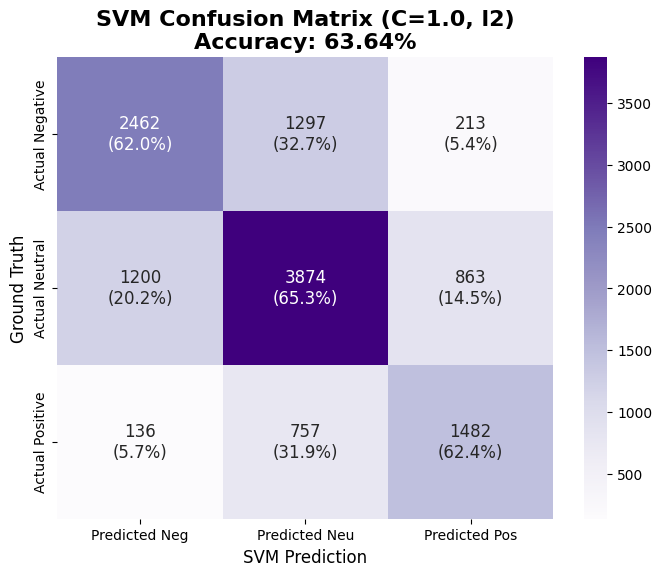

In [6]:
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Preparing memory...")

# --- MEMORY FIX: Downcast to float32 (Halves RAM usage) ---
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

# Free up unneeded variables
gc.collect()

# ==========================================
# 1. Set Your Specific Hyperparameters
# ==========================================
chosen_C = 1.0      # Change this to whatever single value you want to test
chosen_penalty = 'l2'   # 'l1' or 'l2' (Note: 'l1' requires dual=False)

print(f"Training LinearSVC with C={chosen_C} and penalty='{chosen_penalty}'...")
start_time = time.time()

# Instantiate the model directly (No GridSearchCV needed!)
svm_model = LinearSVC(
    C=chosen_C,
    penalty=chosen_penalty,
    dual=False,
    max_iter=2000,
    random_state=config.seed
)

# Fit directly on the full 1.3M dataset
svm_model.fit(X_train_scaled, y_train_svm)

end_time = time.time()
print(f"\n✅ Training Completed in {(end_time - start_time)/60:.2f} minutes!")

# ==========================================
# 2. Evaluate the Model
# ==========================================
print("\nEvaluating on the Test Set...")

y_pred_svm = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test_svm, y_pred_svm)

print(f"\n{'='*30}\nSVM FINAL TEST ACCURACY: {svm_acc:.4%}\n{'='*30}\n")
# print(classification_report(y_test_svm, y_pred_svm, target_names=['Negative', 'Positive']))
# UPDATE: Added 'Neutral' to target_names
print(classification_report(y_test_svm, y_pred_svm, 
                            target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
cm_svm = confusion_matrix(y_test_svm, y_pred_svm)
cm_perc_svm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]
# labels_svm = (np.array(["{0:d}\n({1:.1%})".format(count, perc)
          # for count, perc in zip(cm_svm.flatten(), cm_perc_svm.flatten())])).reshape(2, 2)
# UPDATE: Reshape changed from (2, 2) to (3, 3) for the 3 classes
labels_svm = (np.array(["{0:d}\n({1:.1%})".format(count, perc)
          for count, perc in zip(cm_svm.flatten(), cm_perc_svm.flatten())])).reshape(3, 3)

plt.figure(figsize=(8, 6))
# sns.heatmap(cm_svm, annot=labels_svm, fmt="", cmap='Purples', annot_kws={"size": 14},
            # xticklabels=['Predicted Negative', 'Predicted Positive'],
            # yticklabels=['Actual Negative', 'Actual Positive'])
# UPDATE: Added Neutral labels to the axes
sns.heatmap(cm_svm, annot=labels_svm, fmt="", cmap='Purples', annot_kws={"size": 12},
            xticklabels=['Predicted Neg', 'Predicted Neu', 'Predicted Pos'],
            yticklabels=['Actual Negative', 'Actual Neutral', 'Actual Positive'])
plt.title(f'SVM Confusion Matrix (C={chosen_C}, {chosen_penalty})\nAccuracy: {svm_acc:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('SVM Prediction', fontsize=12)
plt.show()

In [7]:
import joblib

print("Saving SVM components...")

# 1. Save the trained SVM model
joblib.dump(svm_model, 'best_linear_svm.joblib')
print("✅ SVM model saved as 'best_linear_svm.joblib'")

# 2. Save the fitted StandardScaler
joblib.dump(scaler_svm, 'svm_scaler.joblib')
print("✅ Scaler saved as 'svm_scaler.joblib'")

Saving SVM components...
✅ SVM model saved as 'best_linear_svm.joblib'
✅ Scaler saved as 'svm_scaler.joblib'
